In [6]:
import xarray as xr

#### Create a presence ausence dataset

In [7]:
fishing = xr.open_zarr("./data/processed/GFW_AIS.zarr", consolidated=True)
esp_trawl = fishing.where(
    (fishing["flag"] == "ESP") & (fishing["geartype"] == "TRAWLERS"),
    drop=True
)
esp_trawl = esp_trawl.reset_index(["flag", "geartype"], drop=True)
# esp_trawl.to_netcdf("./data/processed/dynamic/ESP_TRAWL.nc")

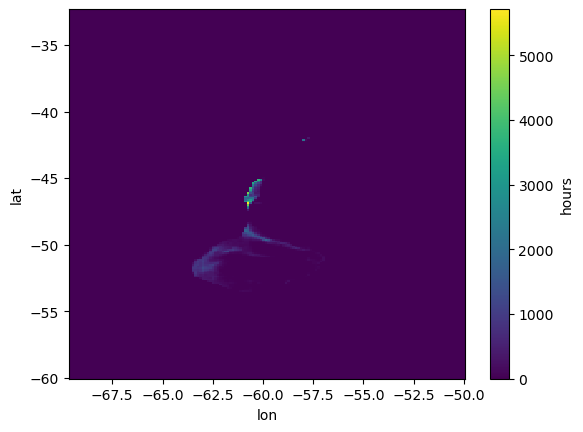

In [8]:
esp_trawl["hours"].sum(dim=["time"]).plot()

In [9]:
presence_esp_trawl = (esp_trawl > 6).astype(int)
presence_esp_trawl = presence_esp_trawl.rename({"hours": "presence"})
presence_esp_trawl.to_netcdf("./data/processed/dynamic/presence_ESP_TRAWL.nc")

OSError: [Errno 22] Invalid argument: 'c:\\Users\\rubar\\Desktop\\TFM\\TFM_PY\\data\\processed\\dynamic\\presence_ESP_TRAWL.nc'

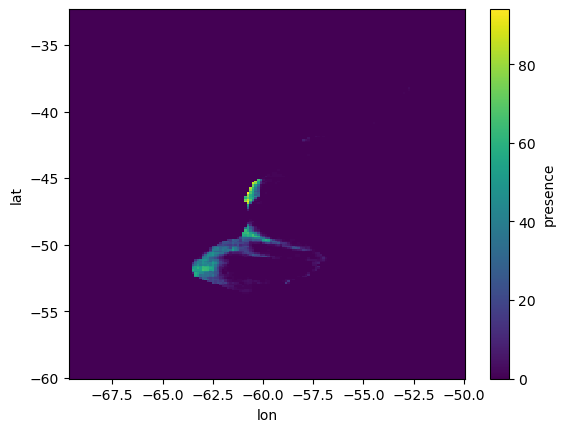

In [ ]:
presence_esp_trawl["presence"].sum(dim=["time"]).plot()